# FedCircuitNet - Training vs. Test Loss

Given a run's tag (the `tag:` field shared by a train/test config pair under `./20261007_configs/`), this notebook draws **one figure with two side-by-side plots**:

1. **Training loss per step** - `Mean Client Train Loss`, tracked once per FL round by `train_aim.py`'s round callback (Aim's `step` axis is the round index).
2. **Test loss per sample** - `Test Loss (dist)`, tracked once per test sample by `test_aim.py`.

Both series are the *same* loss function (`strategy.loss_type` / `biased_loss_s` / `biased_loss_b`), evaluated on different sides of the FL pipeline - the whole point of plotting them together. The loss config is mirrored from the train config into the matching `20261007_configs/*_test.yaml` so `test_aim.py` can build the identical `BiasedMSELoss`; it is intentionally *not* added to the base `config/fedavg_test_*.yaml` files, which only report the distribution-shape metrics (NRMS/SSIM).

The two subplots share their y-axis (`sharey=True`) so the loss scales are directly comparable.

Everything is read from the local Aim repository (`aim.Repo(path=os.getcwd())`), same convention as `show_result.ipynb`.

## Setup and helpers

In [10]:
import os

import numpy as np
import matplotlib.pyplot as plt

from aim import Repo
from aim.storage.context import Context

# Aim repo lives at the FedCircuitNet root (same convention as show_result.ipynb).
repo = Repo(path=os.getcwd())

# `experiment` names set in the 20261007_configs/*.yaml run by run_all_experiments.sh.
# All runs in each phase share one experiment name; a run is told apart by its tag.
TRAIN_EXPERIMENTS = [
    'fedavg_drc_train_20261007',
]

TEST_EXPERIMENTS = [
    'fedavg_drc_test_20261007',
]

In [11]:
def get_runs_by_experiment_name(experiment_name):
    query = (
        'run.active == False and run.archived == False '
        f'and run.experiment == "{experiment_name}"'
    )
    return list(repo.query_runs(query=query, report_mode=0).iter_runs())


def collect_runs(experiment_names):
    """Flatten runs across a list of experiment names, deduped by hash."""
    seen = set()
    runs = []
    for name in experiment_names:
        for wrapper in get_runs_by_experiment_name(name):
            r = wrapper.run
            if r.hash in seen:
                continue
            seen.add(r.hash)
            runs.append(r)
    return runs


def train_scheme_tag(run):
    """Return the run ID for a train run, from its save folder.

    Train yamls store `training.save_path: ./work_dirs/20261007/fedavg_<ID>`,
    the folder their test yamls load the checkpoint from, so a train run and
    its test run get the same label.
    """
    hparams = run.get('hparams') or {}
    save_path = (hparams.get('training') or {}).get('save_path') or ''
    folder = os.path.basename(os.path.normpath(save_path)) if save_path else ''
    if folder.startswith('fedavg_'):
        return folder[len('fedavg_'):]
    return folder or run.hash


def test_scheme_tag(run):
    """Return the run ID for a test run, from the checkpoint dir.

    Test yamls store `checkpoint: ./work_dirs/20261007/fedavg_<ID>/model_round_<T>.pth`,
    so the parent dir gives us the run ID.
    """
    hparams = run.get('hparams') or {}
    checkpoint = hparams.get('checkpoint') or ''
    parent = os.path.basename(os.path.dirname(checkpoint)) if checkpoint else ''
    if parent.startswith('fedavg_'):
        return parent[len('fedavg_'):]
    return parent or run.hash


def metric_series_with_steps(run, name, context=None):
    """Return (steps, values) sorted by step for the given metric."""
    metric = run.get_metric(name, context=Context(context or {}))
    if metric is None:
        return np.array([]), np.array([])

    steps = metric.timestamps.values_numpy()
    vals = metric.values.values_numpy()
    idx = np.argsort(steps)
    return np.sort(idx), vals[idx]


def per_sample_metric(run, name, context=None):
    """Return the raw per-sample values tracked for `name` (insertion order)."""
    metric = run.get_metric(name, context=Context(context or {}))
    return metric.values.values_numpy() if metric is not None else np.array([])

## Available run tags

Tags found in each experiment - pick one of these for `TAG` below.

In [12]:
train_runs_all = collect_runs(TRAIN_EXPERIMENTS)
test_runs_all = collect_runs(TEST_EXPERIMENTS)

train_tags = sorted({train_scheme_tag(r) for r in train_runs_all})
test_tags = sorted({test_scheme_tag(r) for r in test_runs_all})

print('Train tags:', train_tags)
print('Test tags: ', test_tags)

Train tags: ['FH_400r', 'FH_c10', 'FH_c20', 'FH_c5', 'iid_c10', 'iid_c20', 'iid_c5']
Test tags:  ['FH_400r', 'FH_c10', 'FH_c20', 'FH_c5', 'iid_c10', 'iid_c20', 'iid_c5']


## Pick a run

In [13]:
# <-- set this to the run you want to inspect (must exist in both lists above)
TAG = 'FH_c10'

train_run = next((r for r in train_runs_all if train_scheme_tag(r) == TAG), None)
test_run = next((r for r in test_runs_all if test_scheme_tag(r) == TAG), None)

if train_run is None:
    raise ValueError(f'No train run tagged {TAG!r}. Available: {train_tags}')
if test_run is None:
    raise ValueError(f'No test run tagged {TAG!r}. Available: {test_tags}')

train_strategy = (train_run.get('hparams') or {}).get('strategy') or {}
test_strategy = (test_run.get('hparams') or {}).get('strategy') or {}

print(f"[{TAG}] train loss: type={train_strategy.get('loss_type')} "
      f"s={train_strategy.get('biased_loss_s')} b={train_strategy.get('biased_loss_b')}")
print(f"[{TAG}] test  loss: type={test_strategy.get('loss_type')} "
      f"s={test_strategy.get('biased_loss_s')} b={test_strategy.get('biased_loss_b')}")

if not test_strategy.get('loss_type'):
    print(f"[{TAG}] WARNING: test config has no strategy.loss_type - "
          f"test_aim.py will not have tracked 'Test Loss (dist)' for this run.")
elif train_strategy.get('loss_type') != test_strategy.get('loss_type'):
    print(f"[{TAG}] WARNING: train/test loss_type mismatch - the two plots below "
          f"are not directly comparable.")

[FH_c10] train loss: type=BiasedMSELoss s=5 b=0.1
[FH_c10] test  loss: type=BiasedMSELoss s=5 b=0.1


## Training loss per step vs. test loss per sample

Left: `Mean Client Train Loss`, one point per FL round (Aim's `step` axis). Right: `Test Loss (dist)`, one point per test sample. Shared y-axis (`sharey=True`) keeps the two scales comparable.

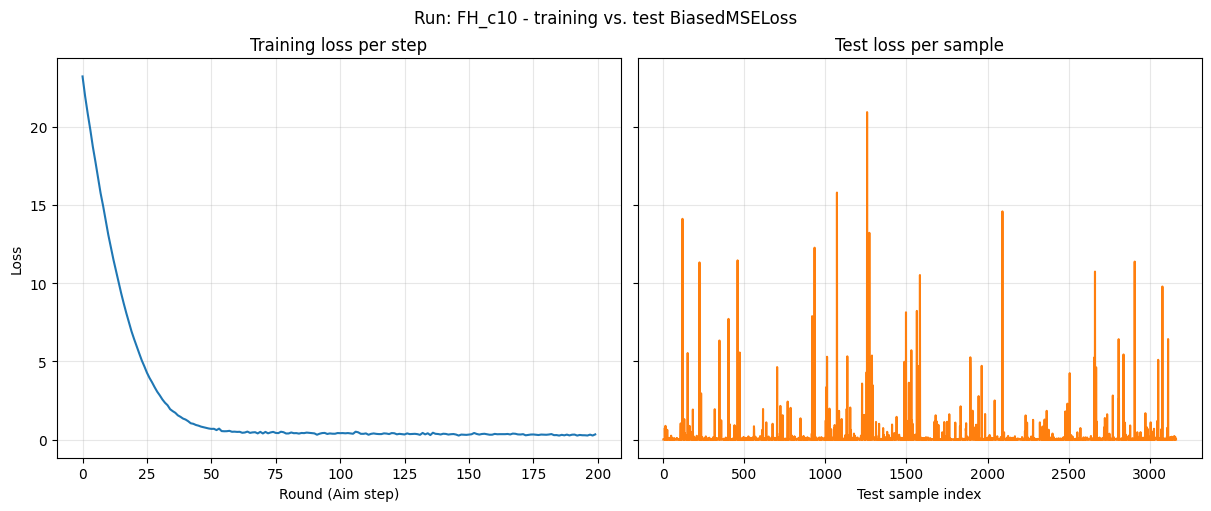

In [14]:
train_steps, train_vals = metric_series_with_steps(
    train_run, 'Mean Client Train Loss', context={'subset': 'train'}
)
test_vals = per_sample_metric(
    test_run, 'Test Loss (dist)', context={'subset': 'test', 'aggregation': 'distribution'}
)
test_steps = np.arange(test_vals.size)

if train_vals.size == 0:
    print(f"[{TAG}] no 'Mean Client Train Loss' found for the train run - nothing to plot on the left.")
if test_vals.size == 0:
    print(f"[{TAG}] no 'Test Loss (dist)' found for the test run - nothing to plot on the right "
          f"(did the test config carry strategy.loss_type?).")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True, sharey=True)
loss_label = train_strategy.get('loss_type', 'loss')
fig.suptitle(f'Run: {TAG} - training vs. test {loss_label}')

if train_vals.size:
    axes[0].plot(train_steps, train_vals, color='tab:blue')
axes[0].set_title('Training loss per step')
axes[0].set_xlabel('Round (Aim step)')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

if test_vals.size:
    axes[1].plot(test_steps, test_vals, color='tab:orange')
axes[1].set_title('Test loss per sample')
axes[1].set_xlabel('Test sample index')
axes[1].grid(True, alpha=0.3)

plt.show()
plt.close(fig)